## Genomics Lab: Simon Alam, Miky Asmare

## Genomics

Leukemia is a cancer of blood-generating tissues. Over 475,000 Americans have Leukemia or are in remission from it. It accounts for 3.3% of all new cancer cases and 3.8% of cancer deaths, with an estimated 66,890 new cases and 23,540 deaths in the U.S. in 2025.

There are two major leukemia families: Acute Lymphoblastic Leukemia (ALLB and ALLT, or ALL), which is cancer of immature lymphoid cells, and Acute Myeloid Leukemia (AML), which is cancer of cancer of immature myeloid cells.

Golub et al. (*Science*, 1999) popularized a dataset including about 7000 genes from 72 patients. The goal is to use genomics data to predict which patients are at risk of ALL versus AML, because the distinction is critical for timely and effective treatment.

## Question 1

Load the `golub.csv` dataset. Relabel all instances of ALLB and ALLT as 0, and all instances of AML as 1. This is the target variable.

In [6]:
df = pd.read_csv('golub.csv')

mapper = {'allB': 0, 'allT': 0, 'aml': 1}
df['outcome'] = df['cancer'].map(mapper)

print(df['outcome'].value_counts())
print(df.shape)

outcome
0    47
1    25
Name: count, dtype: int64
(72, 7136)


## Question 2

Use Linear Regression of the target variable on all of the genes provided. What is your mean squared error? Make a kernel density plot of your residuals, and a scatter plot comparing predicted and actual outcomes.

OLS training MSE: 0.000000


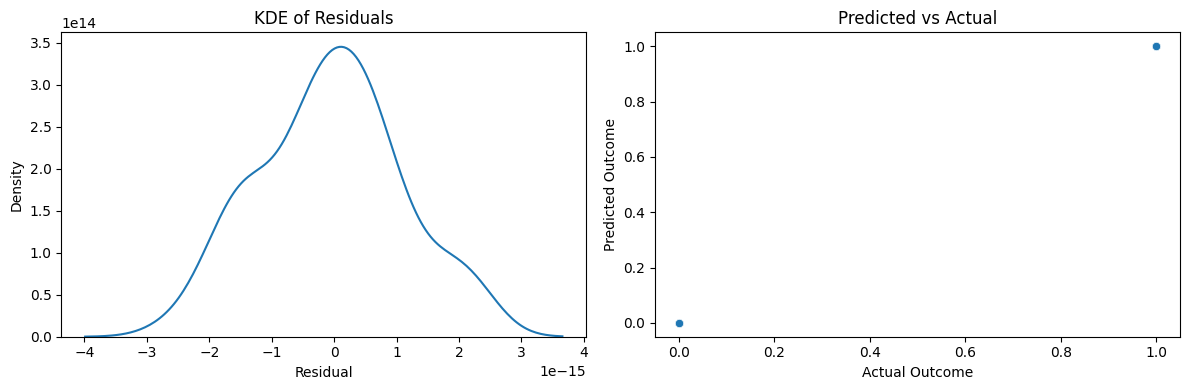

In [7]:
mse = lambda y, y_hat: np.mean((y - y_hat) ** 2)

y = df['outcome']
X = df.drop(['Samples', 'BM.PB', 'Gender', 'Source', 'tissue.mf', 'cancer', 'outcome'], axis=1)

model = LinearRegression()
reg = model.fit(X, y)
y_hat = reg.predict(X)

print(f'OLS training MSE: {mse(y, y_hat):.6f}')

residuals = y_hat - y

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.kdeplot(residuals, ax=axes[0])
axes[0].set_title('KDE of Residuals')
axes[0].set_xlabel('Residual')

sns.scatterplot(x=y, y=y_hat, ax=axes[1])
axes[1].set_title('Predicted vs Actual')
axes[1].set_xlabel('Actual Outcome')
axes[1].set_ylabel('Predicted Outcome')

plt.tight_layout()
plt.show()

The training MSE is essentially zero. With 72 observations and ~7,100 gene predictors, the model is massively overparameterized, meaning OLS can find coefficients that fit every training point exactly. The residuals are on the order of 1e-15, which is floating point rounding error rather than real prediction error. The scatter plot collapses to just two points on the diagonal, confirming the model memorizes every label rather than learning generalizable signal.

## Question 3

Use cross validation to compute the mean squared error of the linear model. Discuss your results from the perspective of the bias variance trade-off.

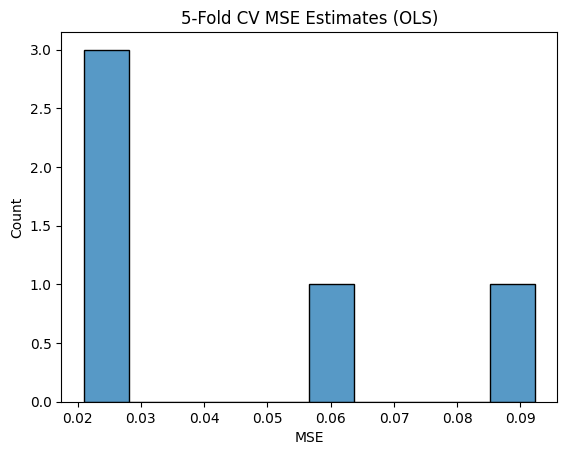

Fold MSEs: [0.0244198  0.05792023 0.09224999 0.02097934 0.02126042]
Mean CV MSE: 0.0434
Std CV MSE:  0.0281


In [8]:
kfold = KFold(n_splits=5, shuffle=True, random_state=100)
scores = cross_val_score(
    model, X, y,
    cv=kfold,
    scoring='neg_mean_squared_error'
)

cv_mse = -scores

sns.histplot(cv_mse, bins=10)
plt.title('5-Fold CV MSE Estimates (OLS)')
plt.xlabel('MSE')
plt.show()

print('Fold MSEs:', cv_mse)
print(f'Mean CV MSE: {np.mean(cv_mse):.4f}')
print(f'Std CV MSE:  {np.std(cv_mse):.4f}')

The mean CV MSE of 0.0434 is dramatically higher than the training MSE of zero, exposing severe overfitting. With ~7,129 predictors and only 72 patients, OLS sits at the high-variance extreme, fitting noise in the training fold rather than true signal. The high standard deviation across folds (0.0281) reinforces this instability, with individual fold MSEs ranging from 0.021 to 0.092 depending on which patients land in the training set. OLS has zero bias on training data but pays a steep price in variance out-of-sample, which is the core bias-variance tradeoff at work.

## Question 4

Use the cross validated LASSO to select a set of highly predictive genes. Which set of genes is selected? How many genes are discarded from the model? Make a scatterplot of your predictions versus the actual values.

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.709e-03, tolerance: 1.632e-03
  model = cd_fast.enet_coordinate_descent(


Optimal alpha: 0.000655
Genes selected: 80
Genes discarded: 7049

Selected genes: ['AF000560_at', 'AF002020_at', 'AF006087_at', 'D26579_at', 'D29956_at', 'D42043_at', 'D50840_at', 'D86982_at', 'HG2161-HT2231_at', 'J04101_at', 'J04164_at', 'L12723_at', 'L13848_at', 'L20941_at', 'M12759_at', 'M17754_at', 'M19507_at', 'M20902_at', 'M22960_at', 'M23197_at', 'M27891_at', 'M28713_at', 'M31994_at', 'M63138_at', 'M84526_at', 'M95178_at', 'M96326_rna1_at', 'M98539_at', 'U10868_at', 'U14588_at', 'U30828_at', 'U34877_at', 'U36621_cds2_at', 'U46751_at', 'U50136_rna1_at', 'U51127_at', 'U60062_at', 'U82313_at', 'U82759_at', 'U88666_at', 'U89942_at', 'X04143_at', 'X14789_at', 'X16706_at', 'X53331_at', 'X56741_at', 'X63753_at', 'X66533_at', 'X66867_cds1_at', 'X69111_at', 'X81479_at', 'X83378_at', 'X95735_at', 'X96698_at', 'Y00636_at', 'Y07604_at', 'Y07755_at', 'Y10207_at', 'Y12670_at', 'M96843_at', 'X58072_at', 'AC002477_s_at', 'L15326_s_at', 'X57351_at', 'K02777_s_at', 'U37055_rna1_s_at', 'U59632_s_a

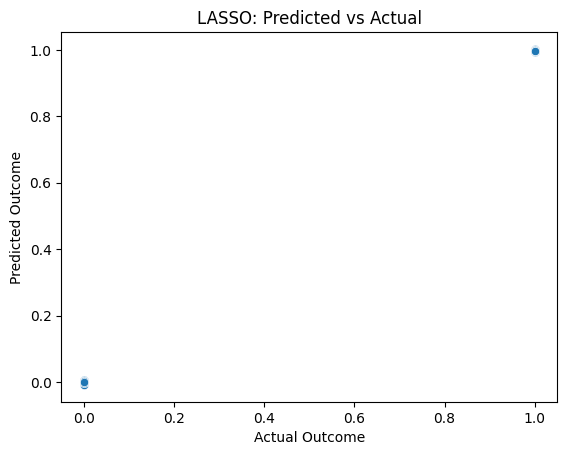

In [9]:
scaler = StandardScaler()
X_sc = scaler.fit_transform(X)

alpha_grid = np.logspace(-4, -2, num=50)
lasso_cv = LassoCV(cv=10, alphas=alpha_grid, random_state=100)
lasso_cv.fit(X_sc, y)

alpha_star = lasso_cv.alpha_
print(f'Optimal alpha: {alpha_star:.6f}')

final_lasso = Lasso(alpha=alpha_star, max_iter=10000)
final_lasso.fit(X_sc, y)
coefs_star = final_lasso.coef_

nonzero_idx = np.where(coefs_star != 0)[0]
selected_genes = X.columns[nonzero_idx]

print(f'Genes selected: {len(selected_genes)}')
print(f'Genes discarded: {len(coefs_star) - len(selected_genes)}')
print('\nSelected genes:', list(selected_genes))

y_hat_lasso = final_lasso.predict(X_sc)

sns.scatterplot(x=y, y=y_hat_lasso)
plt.title('LASSO: Predicted vs Actual')
plt.xlabel('Actual Outcome')
plt.ylabel('Predicted Outcome')
plt.show()

The cross-validated LASSO selected 80 genes out of 7,129, discarding 7,049 (98.9%) by shrinking their coefficients exactly to zero. The selected genes are those with the strongest and most consistent association with ALL vs. AML status across folds. The scatter plot shows predictions clustering tightly at 0 for ALL patients and 1 for AML patients, indicating the model cleanly separates the two classes on the training data using only a small fraction of the available genes.

## Question 5

Make a plot that shows the cross validated MSE as $\alpha$ varies. For what values of $\alpha$ is the LASSO underfitting? Overfitting? What is the optimal penalty hyperparameter that minimizes expected MSE?

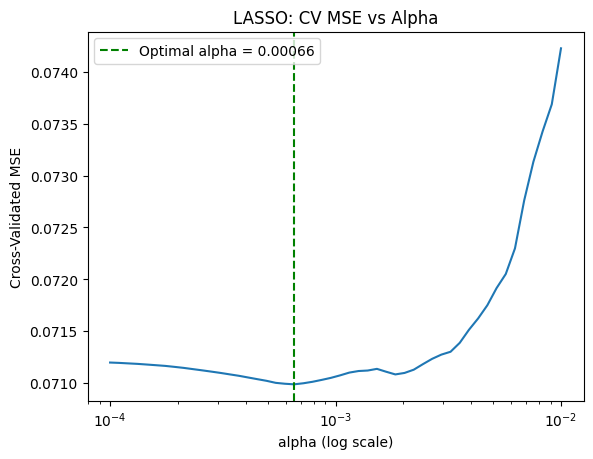

Optimal alpha: 0.000655


In [10]:
cv_mse_by_alpha = np.mean(lasso_cv.mse_path_, axis=1)

sns.lineplot(x=lasso_cv.alphas_, y=cv_mse_by_alpha)
plt.axvline(x=alpha_star, color='green', linestyle='--', linewidth=1.5, label=f'Optimal alpha = {alpha_star:.5f}')
plt.xscale('log')
plt.xlabel('alpha (log scale)')
plt.ylabel('Cross-Validated MSE')
plt.title('LASSO: CV MSE vs Alpha')
plt.legend()
plt.show()

print(f'Optimal alpha: {alpha_star:.6f}')

At small values of alpha (left of the green line), the penalty is weak and the LASSO retains too many genes, overfitting by capturing noise alongside true signal. At large values of alpha (right of the green line), the penalty is too strong, shrinking genuinely predictive genes to zero and underfitting by introducing too much bias. The optimal alpha of 0.000655 sits at the bottom of the curve, minimizing expected CV MSE by balancing these two sources of error.

## Question 6

Explain why linear regression performs perfectly on the training set, but the LASSO provides better predictions overall.

Linear regression performs perfectly on the training set because the problem is severely underdetermined. With 72 patients and ~7,129 gene predictors, there are infinitely many coefficient vectors that produce zero training error, and OLS finds one of them. Because OLS has no incentive to prefer simpler solutions, it assigns nonzero weights to many genes that are only spuriously correlated with the outcome in the training sample, and those coefficients fail to generalize to new patients.

LASSO adds an L1 penalty that forces most coefficients to zero, performing automatic variable selection. It accepts a small amount of bias, since the selected genes' coefficients are slightly shrunk toward zero, in exchange for a large reduction in variance. By retaining only the genes with consistently strong predictive signal across folds, the resulting model generalizes far better to new patients. This is the bias-variance tradeoff in practice: OLS minimizes training error at the cost of high variance, while LASSO tolerates some bias to achieve much lower variance and better expected test performance.

## Question 7

Why do regularization methods lend themselves to scenarios like precision health?

Precision health is characterized by a structural imbalance where the number of measured features, such as genes, proteins, and biomarkers, vastly exceeds the number of patients available for a given condition. Collecting genomic data is cheap relative to recruiting study participants, so datasets with thousands of predictors and only dozens of outcomes are the norm.

Regularization methods are well suited to this setting for several reasons. First, they prevent overfitting in high-dimensional spaces where OLS would interpolate noise. Second, methods like LASSO perform implicit feature selection, identifying the small subset of biomarkers that truly predict an outcome, which is scientifically valuable since clinicians need interpretable and actionable signals rather than a model using thousands of genes. Third, regularization produces stable coefficient estimates because the penalty discourages large weights, meaning small changes in the training sample do not wildly alter which genes are selected. Finally, cross-validation provides a principled, data-driven way to choose the regularization strength, making the approach practical even without strong prior knowledge about which genes matter.

## Question 8

What are the risks of applying methods like the Lasso to precision health questions, where interventions will then be taken to optimize patient health?

Even with cross-validation, LASSO can select genes that happen to correlate with the outcome in a particular dataset without any real causal relationship. With small sample sizes and thousands of predictors, this is hard to avoid. This matters clinically because the model may be picking up on downstream markers of disease rather than the actual drivers, meaning interventions built around those genes could target the wrong mechanisms. Genomic datasets also tend to oversample patients of European ancestry, so predictions may be less accurate or even misleading for patients from other backgrounds.

Deploying these models in practice also creates feedback problems. Once treatments are given based on model predictions, the patient population changes, and a model trained on untreated patients may perform worse in ways that are difficult to notice. When something goes wrong, it is also hard to explain why the model made a particular recommendation, which makes accountability difficult for both patients and regulators. These risks do not disqualify regularization methods from precision health, but they do require careful validation and ongoing monitoring before predictions drive real treatment decisions.